# Emparelhamento Máximo Estável (SPA)
**Disciplina:** Teoria e Aplicação de Grafos  
**Turma:** A - 2026/1  
**Professor:**   Dr. Díbio Leandro Borges


## Integrantes
* Gabriel Alexandre Gomes - 241038942
* Henrique de Almeida Santos - 241020840
* Nyvea Paulla Tavares Monteiro - 241040207


## Descrição do Projeto
Este projeto consiste na elaboração e implementação de uma variação do algoritmo de Gale-Shapley para resolver o problema de **Alocação de Alunos a Projetos (Student-Project Allocation - SPA)**. O objetivo é realizar um emparelhamento estável máximo entre 200 alunos e 50 projetos com 80 vagas no total, respeitando as preferências dos alunos, as notas agregadas e os requisitos mínimos/vagas de cada projeto. O programa apresenta o comportamento visual do grafo bipartido ao longo de 10 iterações em laço utilizando caminhos alternados.

##### 1 — Importações e Configuração de Entrada
Este bloco carrega as ferramentas matemáticas de grafos, visualização e expressões regulares, além de baixar o arquivo de dados do repositório oficial.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import re
import matplotlib.cm as cm
import time
from IPython.display import clear_output
import pandas as pd
from IPython.display import display

# Baixa o arquivo de entrada direto do repositório público do GitHub
!wget -q https://raw.githubusercontent.com/Bielzada444/student-project-allocation-spa/refs/heads/main/data/entradaProj2.26TAG.txt


##### 2 — Extração e Estruturação de Dados Brutos
Esta função realiza a leitura do arquivo texto e utiliza expressões regulares para limpar e isolar os atributos de alunos e projetos em dicionários nativos.

In [ ]:
def carregar_dados(caminho_arquivo):
    projetos = {}
    alunos = {}

    with open(caminho_arquivo, 'r') as arquivo:
        linhas = arquivo.readlines()

    for linha in linhas:
        linha = linha.strip()
        if not linha or linha.startswith('//'):
            continue

        if linha.startswith('(P') and ':' not in linha:
            dados = re.findall(r'[A-Z0-9]+', linha)
            if len(dados) == 3:
                id_proj = dados[0]
                vagas = int(dados[1])
                nota_min = int(dados[2])

                projetos[id_proj] = {
                    'vagas': vagas,
                    'nota_minima': nota_min,
                    'alunos': [],
                }

        elif linha.startswith('(A'):
            dados = re.findall(r'[A-Z0-9]+', linha)
            if len(dados) >= 3:
                id_aluno = dados[0]
                nota_aluno = int(dados[-1])
                prefs = dados[1:-1]

                alunos[id_aluno] = {
                    'preferencias': prefs,
                    'nota': nota_aluno,
                    'alocado_em': None
                }

    return projetos, alunos

# O arquivo agora é carregado automaticamente do que foi baixado do GitHub!
projetos, alunos = carregar_dados('entradaProj2.26TAG.txt')

print("Dados do P1:", projetos.get('P1'))
print("Dados do A1:", alunos.get('A1'))


Dados do P1: {'vagas': 2, 'nota_minima': 5, 'alunos': []}
Dados do A1: {'preferencias': ['P1', 'P30', 'P50'], 'nota': 5, 'alocado_em': None}


##### 3 — Construção das Listas de Preferências dos Projetos
Função responsável por mapear os alunos que cumpriram os requisitos de nota mínima de cada projeto e ordenar essas filas pelo critério de mérito.

In [ ]:
def gerar_preferencias_projetos(projetos, alunos):
    # Passo 1: Filtrar quem cumpre os requisitos
    for id_aluno, dados_aluno in alunos.items():
        nota_aluno = dados_aluno['nota']

        for projeto_escolhido in dados_aluno['preferencias']:
            if projeto_escolhido in projetos:
                nota_minima_exigida = projetos[projeto_escolhido]['nota_minima']

                if nota_aluno >= nota_minima_exigida:
                    projetos[projeto_escolhido]['alunos'].append((id_aluno, nota_aluno))

    # Passo 2: Ordenar as listas de cada projeto pela nota (maior para a menor)
    for id_proj, dados_proj in projetos.items():
        # Ordenamos a lista de tuplas baseando-se na nota (índice 1)
        lista_ordenada = sorted(dados_proj['alunos'], key=lambda x: x[1], reverse=True)

        # Guardamos apenas os IDs dos alunos, agora na chave 'alunos'
        projetos[id_proj]['alunos'] = [pacotinho[0] for pacotinho in lista_ordenada]

    return projetos

##### 4 — Núcleo Algorítmico Gale-Shapley (Variação SPA-S)
Implementação do mecanismo de propostas e rejeições sequenciais que atua como caminho alternado para expandir o tamanho do emparelhamento estável.

In [ ]:
def executar_gale_shapley(projetos, alunos):
    # 1. SETUP INICIAL
    estudantes_livres = list(alunos.keys())
    for p in projetos:
        projetos[p]['alocados'] = []
    for a in alunos:
        alunos[a]['indice_proposta'] = 0
        alunos[a]['alocado_em'] = None

    historico_iteracoes = []

    # 2. LAÇO PASSO A PASSO (ALUNO POR ALUNO)
    while estudantes_livres:
        id_aluno = estudantes_livres.pop(0)
        dados_aluno = alunos[id_aluno]

        # Se esgotou as opções do aluno, ele fica sem projeto
        if dados_aluno['indice_proposta'] >= len(dados_aluno['preferencias']):
            continue

        id_projeto_alvo = dados_aluno['preferencias'][dados_aluno['indice_proposta']]
        dados_aluno['indice_proposta'] += 1

        dados_projeto = projetos.get(id_projeto_alvo)

        # Inicializa listas vazias para o registro visual desta iteração específica
        propostas = []
        temporarios = []
        rejeicoes = []

        # Validação: o projeto existe e o aluno cumpre o requisito mínimo?
        if dados_projeto and (id_aluno in dados_projeto['alunos']):
            # Registra que uma proposta ativa está acontecendo agora
            propostas.append((id_projeto_alvo, id_aluno))

            # Caso 1: Vaga disponível
            if len(dados_projeto['alocados']) < dados_projeto['vagas']:
                dados_projeto['alocados'].append(id_aluno)
                dados_aluno['alocado_em'] = id_projeto_alvo

            # Caso 2: Projeto cheio, haverá disputa (Batalha de Notas)
            else:
                lista_pref_proj = dados_projeto['alunos']
                pior_alocado = dados_projeto['alocados'][0]
                for alocado in dados_projeto['alocados']:
                    if lista_pref_proj.index(alocado) > lista_pref_proj.index(pior_alocado):
                        pior_alocado = alocado

                # O novato é melhor que o pior alocado atual?
                if lista_pref_proj.index(id_aluno) < lista_pref_proj.index(pior_alocado):
                    # Desaloca o pior
                    dados_projeto['alocados'].remove(pior_alocado)
                    alunos[pior_alocado]['alocado_em'] = None
                    estudantes_livres.append(pior_alocado)
                    rejeicoes.append((id_projeto_alvo, pior_alocado))

                    # Aloca o novato
                    dados_projeto['alocados'].append(id_aluno)
                    dados_aluno['alocado_em'] = id_projeto_alvo
                else:
                    # O novato é rejeitado
                    rejeicoes.append((id_projeto_alvo, id_aluno))
                    estudantes_livres.append(id_aluno)
        else:
            # Rejeição automática por falta de nota mínima ou projeto fantasma
            rejeicoes.append((id_projeto_alvo, id_aluno))
            estudantes_livres.append(id_aluno)

        # Mapeia todas as alocações estáveis/temporárias mantidas até este exato segundo
        for p_id, p_dados in projetos.items():
            for alocado in p_dados['alocados']:
                temporarios.append((p_id, alocado))

        # Guarda o estado atualizado da foto
        historico_iteracoes.append({
            'propostas': propostas,
            'temporarios': temporarios,
            'rejeicoes': rejeicoes
        })

    return projetos, alunos, historico_iteracoes

##### 5 — Interface de Modelagem Visual do Grafo
Função gráfica que posiciona os vértices no modelo clássico bipartido vertical e aplica as cores estritas para propostas, aceites e rejeições.

In [ ]:
def plotar_grafo_estado(projetos, alunos, estado_iteracao, numero_iteracao, e_final=False):
    G = nx.Graph()
    nos_projetos = list(projetos.keys())
    nos_alunos = list(alunos.keys())

    G.add_nodes_from(nos_projetos, bipartite=0)
    G.add_nodes_from(nos_alunos, bipartite=1)

    # 1. POSIÇÕES: O LAYOUT "SANDUÍCHE"
    pos = {}
    fator_distancia = 1.8

    # Dividimos os alunos exatamente no meio
    meio = len(nos_alunos) // 2
    alunos_topo = nos_alunos[:meio]
    alunos_baixo = nos_alunos[meio:]

    # Camada Superior (y = 2): Primeira metade dos alunos
    for i, aluno in enumerate(alunos_topo):
        pos[aluno] = (i * fator_distancia, 2)

    # Camada Inferior (y = 0): Segunda metade dos alunos
    for i, aluno in enumerate(alunos_baixo):
        pos[aluno] = (i * fator_distancia, 0)

    # Camada Central (y = 1): Todos os projetos
    # A largura total é ditada por quem tem 100 itens (as linhas de alunos)
    x_max_alunos = (len(alunos_topo) - 1) * fator_distancia
    passo_proj = x_max_alunos / max(1, len(nos_projetos) - 1)

    for i, proj in enumerate(nos_projetos):
        pos[proj] = (i * passo_proj, 1)

    # 2. TELA: Dimensões (28, 10)
    plt.figure(figsize=(28, 10))

    titulo = f"Emparelhamento Estável (Passo {numero_iteracao})" if e_final else f"Iteração {numero_iteracao}"
    plt.title(titulo, fontsize=24, fontweight='bold', pad=40)

    # 3. NÓS: Tamanhos, espessura, formato, cor
    nx.draw_networkx_nodes(G, pos, nodelist=nos_projetos, node_color='#FFD700', node_shape='s', node_size=800, edgecolors='black', linewidths=2.0) #s é quadrado
    nx.draw_networkx_nodes(G, pos, nodelist=nos_alunos, node_color='#87CEFA', node_shape='o', node_size=500, edgecolors='black', linewidths=2.0)#o é bolinha

    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')

    #arestas: cor, tracejado, espessura
    if estado_iteracao['rejeicoes']:
        nx.draw_networkx_edges(G, pos, edgelist=estado_iteracao['rejeicoes'], edge_color='red', style='dotted', width=1.8, alpha=0.9)
    if estado_iteracao['propostas'] and not e_final:
        nx.draw_networkx_edges(G, pos, edgelist=estado_iteracao['propostas'], edge_color='orange', width=2.5, alpha=0.8)
    if estado_iteracao['temporarios']:
        cor_temp = 'darkgreen' if e_final else 'blue'
        nx.draw_networkx_edges(G, pos, edgelist=estado_iteracao['temporarios'], edge_color=cor_temp, width=3.0, alpha=0.9)

    # 5. LEGENDAS LATERAIS (Para identificar cada uma das 3 linhas)
    x_fim = x_max_alunos
    deslocamento_legenda = fator_distancia * 2

    plt.text(x_fim + deslocamento_legenda, 2, "⬅ ALUNOS (Parte 1)", fontsize=10, fontweight='bold', va='center', color='black')
    plt.text(x_fim + deslocamento_legenda, 1, "⬅ PROJETOS", fontsize=10, fontweight='bold', va='center', color='black')
    plt.text(x_fim + deslocamento_legenda, 0, "⬅ ALUNOS (Parte 2)", fontsize=10, fontweight='bold', va='center', color='black')

    # 6. LEGENDA DE CORES
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='orange', lw=3, label='1) Proposta Ativa'),
        Line2D([0], [0], color='blue', lw=3, label='2) Emparelhamento Temp.'),
        Line2D([0], [0], color='red', lw=3, linestyle='dotted', label='3) Rejeição')
    ]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 1.00), fontsize=14, ncol=3)

    # 7. LIMITES DE ESPAÇO AJUSTADOS
    # O eixo Y agora vai de -0.4 até 2.4 para acomodar as 3 linhas de forma perfeitamente centralizada
    plt.ylim(-0.4, 2.4)
    plt.xlim(-2, x_fim + (fator_distancia * 12))

    plt.axis('off')
    plt.subplots_adjust(left=0.01, right=0.99, top=0.85, bottom=0.05)
    plt.show()


##### 6 — Painel de Controle e Execução da Animação
Bloco que centraliza a chamada das funções e executa a animação em laço das 10 primeiras iterações, limpando o output para simular o fluxo dinâmico.

Animação das 10 primeiras rodadas concluída!
Abaixo, o Emparelhamento Estável Máximo Final:


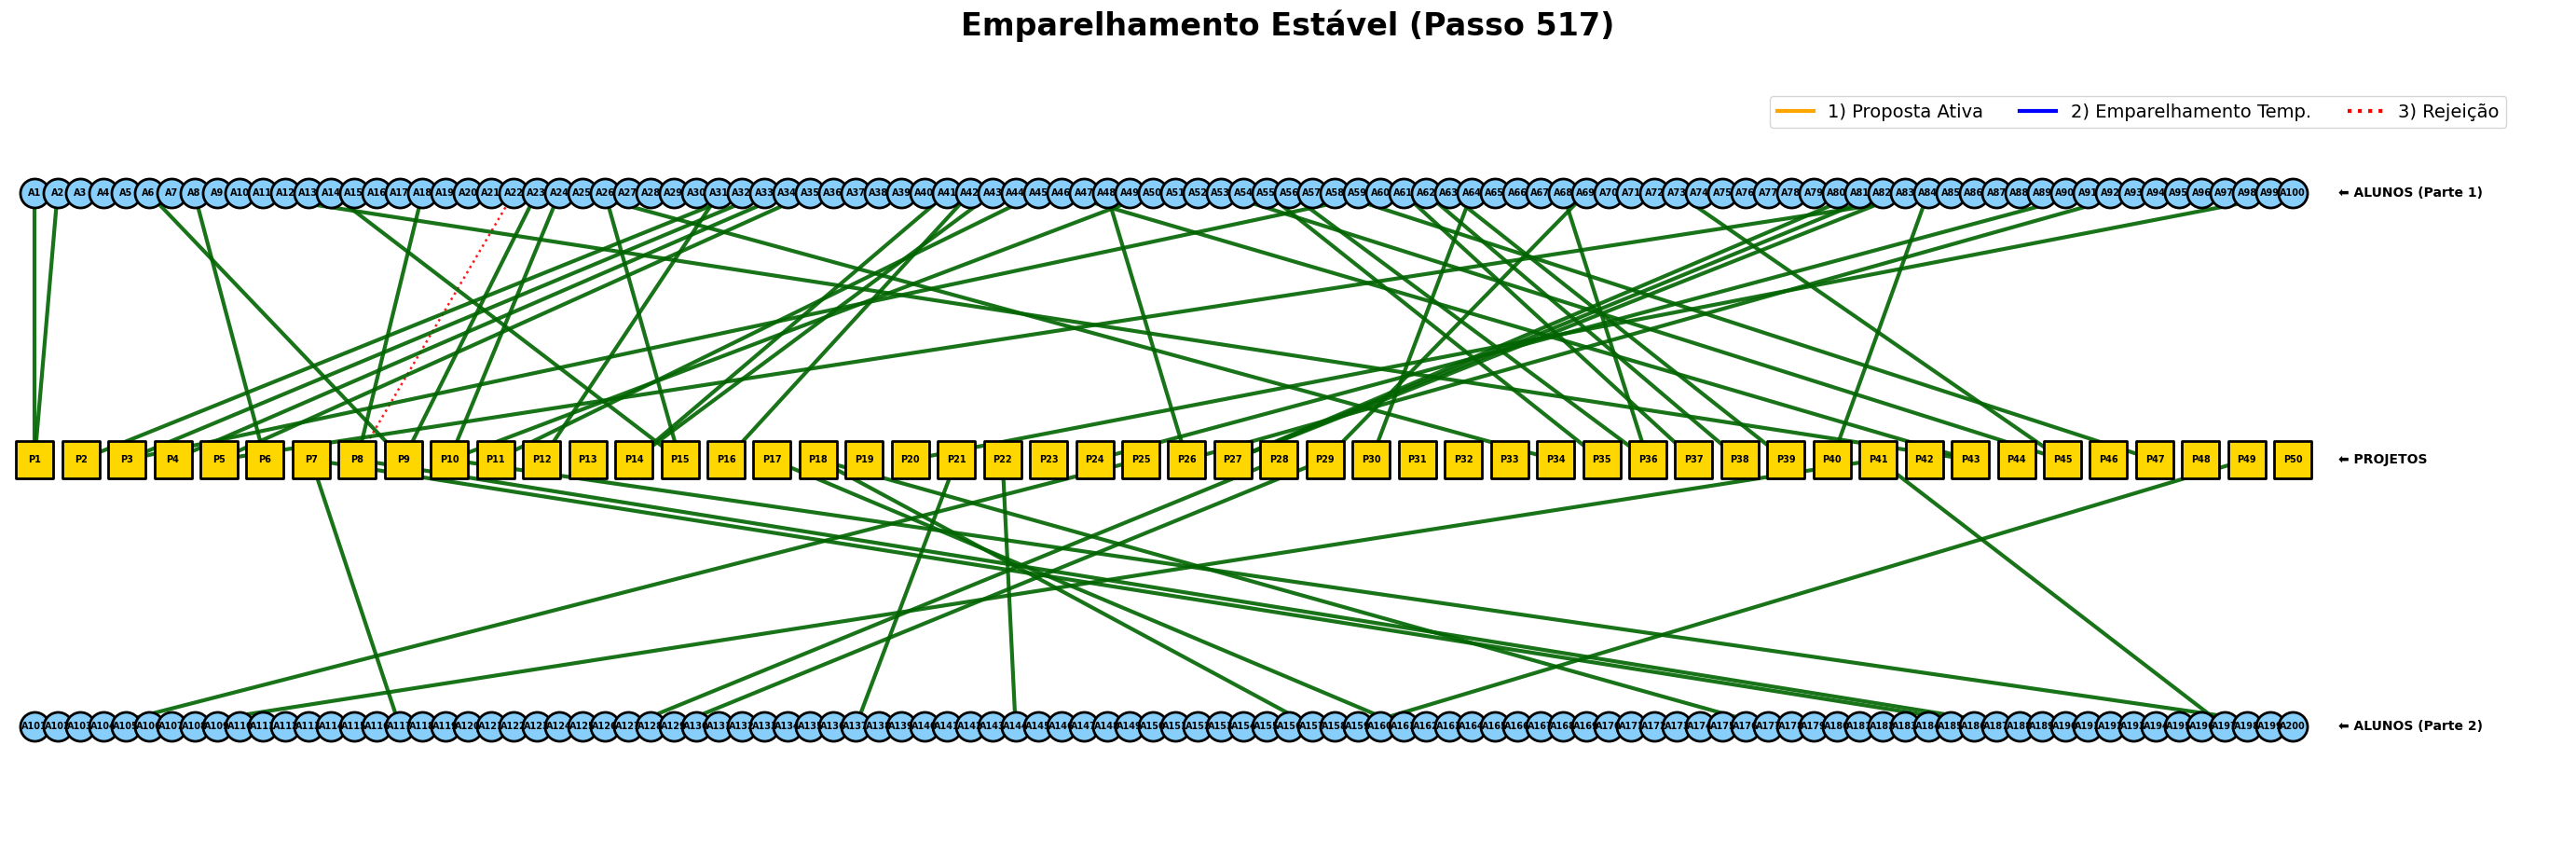

In [ ]:
# Célula 7: Painel de Controle Principal (Execução e Visualização Vertical)
# 1. Carregamos e preparamos os dados
caminho_arquivo = 'entradaProj2.26TAG.txt'
projetos_brutos, alunos_brutos = carregar_dados(caminho_arquivo)
projetos_com_preferencias = gerar_preferencias_projetos(projetos_brutos, alunos_brutos)

# 2. Rodamos o Cérebro do Algoritmo (Agora processando em "Rodadas" completas)
projetos_finais, alunos_finais, historico = executar_gale_shapley(projetos_com_preferencias, alunos_brutos)

total_passos = len(historico)
print(f"O algoritmo processou todas as colisões e alcançou a estabilidade total em {total_passos} rodadas.\n")

# 3. Lógica de Plotagem (Orientação Vertical)
# ==========================================
# CÓDIGO DE ANIMAÇÃO
# ==========================================
print("Preparando o visualizador de iterações...")
time.sleep(1.5)

for i in range(10):
    clear_output(wait=True)
    plotar_grafo_estado(projetos_finais, alunos_finais, historico[i], numero_iteracao=i+1, e_final=False)
    time.sleep(1.5)

clear_output(wait=True)
print("Animação das 10 primeiras rodadas concluída!")
print("Abaixo, o Emparelhamento Estável Máximo Final:")
plotar_grafo_estado(projetos_finais, alunos_finais, historico[-1], numero_iteracao=len(historico), e_final=True)

##### 7 — Extração de Métricas e Matriz de Ganhos/Perdas
Esta célula utiliza a biblioteca Pandas para formatar o índice de preferência dos projetos e estruturar a tabela final de casamentos com o rank de cada lado.

In [ ]:
# 1. ÍNDICE DE PREFERÊNCIA POR PROJETO
preferencias_proj = {p: {'1ª Opção': 0, '2ª Opção': 0, '3ª Opção': 0, 'Total': 0} for p in projetos_brutos}
for a_id, a_dados in alunos_brutos.items():
    for i, p_id in enumerate(a_dados['preferencias']):
        if p_id in preferencias_proj:
            if i == 0: preferencias_proj[p_id]['1ª Opção'] += 1
            elif i == 1: preferencias_proj[p_id]['2ª Opção'] += 1
            elif i == 2: preferencias_proj[p_id]['3ª Opção'] += 1
            preferencias_proj[p_id]['Total'] += 1

df_indice = pd.DataFrame.from_dict(preferencias_proj, orient='index')
df_indice = df_indice.sort_values(by='Total', ascending=False)
df_indice.index.name = 'Projeto'

print("="*60)
print("ÍNDICE DE PREFERÊNCIA POR PROJETO (Top 10 mais desejados)")
print("="*60)
display(df_indice.head(10))

ÍNDICE DE PREFERÊNCIA POR PROJETO (Top 10 mais desejados)


,1ª Opção,2ª Opção,3ª Opção,Total
Projeto,,,,
P30,10,13,4,27
P8,10,1,14,25
P27,6,14,4,24
P34,2,11,10,23
P4,9,4,10,23
P40,5,11,6,22
P10,6,1,14,21
P19,4,17,0,21
P38,9,3,8,20


In [ ]:
# 2. MATRIZ FINAL DE EMPARELHAMENTO
linhas_matriz = []
for p_id, p_dados in projetos_finais.items():
    for a_id in p_dados['alocados']:
        try:
            ordem_aluno = alunos_brutos[a_id]['preferencias'].index(p_id) + 1
            str_ordem_aluno = f"{ordem_aluno}ª Escolha"
        except ValueError:
            str_ordem_aluno = "Não listado"

        try:
            pos_lista_proj = p_dados['alunos'].index(a_id) + 1
            total_lista = len(p_dados['alunos'])
            str_ordem_proj = f"{pos_lista_proj}º (Top {pos_lista_proj} de {total_lista})"
        except ValueError:
            str_ordem_proj = "Sem requisito"

        linhas_matriz.append({
            'Projeto Emparelhado': p_id,
            'Aluno': a_id,
            'Classificação do Aluno (Lista do Projeto)': str_ordem_proj,
            'Classificação do Projeto (Lista do Aluno)': str_ordem_aluno
        })

df_matriz = pd.DataFrame(linhas_matriz)
df_matriz = df_matriz.sort_values(by=['Projeto Emparelhado', 'Classificação do Aluno (Lista do Projeto)'])
df_matriz.reset_index(drop=True, inplace=True)
df_matriz.index += 1

print("="*80)
print("MATRIZ FINAL DOS EMPARELHAMENTOS (Ganhos e Perdas)")
print("="*80)
display(df_matriz.style.set_properties(**{'text-align': 'center'}))

MATRIZ FINAL DOS EMPARELHAMENTOS (Ganhos e Perdas)


,Projeto Emparelhado,Aluno,Classificação do Aluno (Lista do Projeto),Classificação do Projeto (Lista do Aluno)
1,P1,A1,1º (Top 1 de 5),1ª Escolha
2,P1,A2,2º (Top 2 de 5),1ª Escolha
3,P10,A200,1º (Top 1 de 10),2ª Escolha
4,P10,A24,4º (Top 4 de 10),1ª Escolha
5,P10,A50,5º (Top 5 de 10),3ª Escolha
6,P11,A45,1º (Top 1 de 5),1ª Escolha
7,P12,A31,1º (Top 1 de 8),1ª Escolha
8,P14,A41,2º (Top 2 de 7),1ª Escolha
9,P14,A43,3º (Top 3 de 7),2ª Escolha
10,P15,A14,2º (Top 2 de 9),3ª Escolha


In [ ]:
print(df_matriz['Classificação do Projeto (Lista do Aluno)'].value_counts().sort_index())

Classificação do Projeto (Lista do Aluno)
1ª Escolha    36
2ª Escolha    11
3ª Escolha    11
Name: count, dtype: int64
